In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_datalo = f'../data/quaia_G20.0.fits'
fn_datahi = f'../data/quaia_G20.5.fits'

fn_datalo_zbin0 = f'../data/quaia_G20.0_zsplit2bin0.fits'
fn_datalo_zbin1 = f'../data/quaia_G20.0_zsplit2bin1.fits'

fn_datahi_zbin0 = f'../data/quaia_G20.5_zsplit2bin0.fits'
fn_datahi_zbin1 = f'../data/quaia_G20.5_zsplit2bin1.fits'

fn_randlo = f'../data/randoms/random_G20.0_10x.fits'
fn_randhi = f'../data/randoms/random_G20.5_10x.fits'

fn_randlo_zbin0 = f'../data/randoms/random_G20.0_zsplit2bin0_10x.fits'
fn_randlo_zbin1 = f'../data/randoms/random_G20.0_zsplit2bin1_10x.fits'

fn_randhi_zbin0 = f'../data/randoms/random_G20.5_zsplit2bin0_10x.fits'
fn_randhi_zbin1 = f'../data/randoms/random_G20.5_zsplit2bin1_10x.fits'

In [4]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

In [5]:
fn_sello_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin0.fits'
fn_sello_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin1.fits'

fn_selhi_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin0.fits'
fn_selhi_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin1.fits'

## Parameters

In [6]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [7]:
G_hi = 20.5
G_lo = 20.0

In [8]:
nthreads = 18

In [9]:
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

In [10]:
selfunc_hi_zbin0 = hp.fitsfunc.read_map(fn_selhi_zbin0)
selfunc_hi_zbin1 = hp.fitsfunc.read_map(fn_selhi_zbin1)

In [11]:
mask_type = 'selfunc'

# Visuals

In [12]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, mask_type = 'selfunc')

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [13]:
cmap_reds = sns.color_palette("Reds_r", as_cmap = True)
cmap_blues = sns.color_palette("Blues_r", as_cmap = True)

In [14]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [15]:
z_array = [0,1]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(z_array)))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_red, cmap_blue]

In [16]:
blue = np.mean(cmap_blue, axis = 0)
red = np.mean(cmap_red, axis = 0)

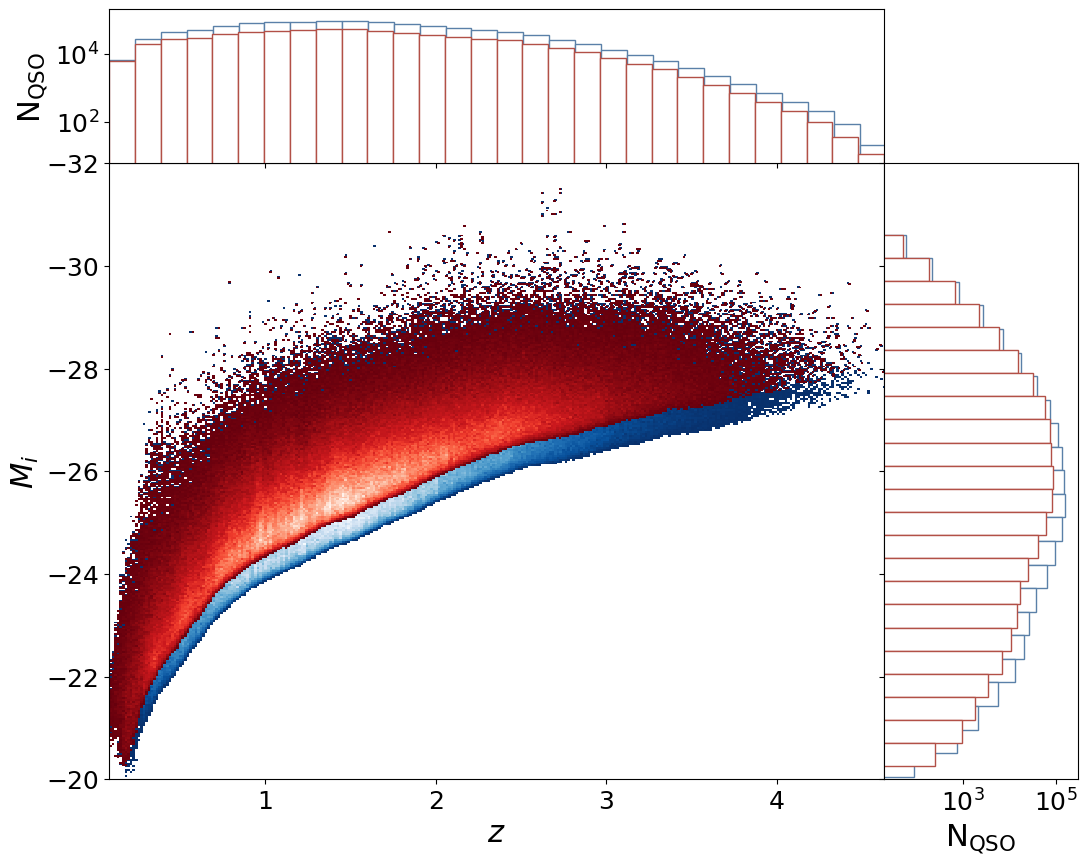

In [17]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
quaia.absolute(tab_datalo, G_lo)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap_blues, bins = 300, 
                                       cmin = 1)
h1, xedges, yedges, image = ax1.hist2d(tab_datalo['redshift_quaia'][mask_datalo], tab_datalo['M_i'][mask_datalo], cmap = cmap_reds, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = blue, bins = 30)
ax2.hist(tab_datalo['redshift_quaia'][mask_datalo], color = 'white', edgecolor = red, bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = blue, orientation = 'horizontal', bins = 25)
ax3.hist(tab_datalo['M_i'][mask_datalo], color = 'white', edgecolor = red, orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in three L bins
## $\xi(s)$

In [18]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# # Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 155.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [19]:
L_array = [0,1,2,3]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(L_array)))[::-1]
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(L_array)))[::-1]
cmaps = [cmap_red, cmap_blue]
tabs = [tab_datalo[mask_datalo], tab_datahi[mask_datahi]]
G_array = [G_lo, G_hi]
labels = ['0-25$^\mathrm{th}$', '25-50$^\mathrm{th}$', '50-75$^\mathrm{th}$', '75-100$^\mathrm{th}$']

_G20.0_Lsplit4bin0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0-25$^\mathrm{th}$ -41.77204574920549 -26.825272531318287 

_G20.0_Lsplit4bin1


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


25-50$^\mathrm{th}$ -26.825270527538738 -25.94842027213946 

_G20.0_Lsplit4bin2


...

25-50$^\mathrm{th}$ -26.47094992980535 -25.588946704465727 

_G20.5_Lsplit4bin2


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


50-75$^\mathrm{th}$ -25.588946100071727 -24.71853079232911 

_G20.5_Lsplit4bin3


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


75-100$^\mathrm{th}$ -24.71852326551791 -20.05062846457238 



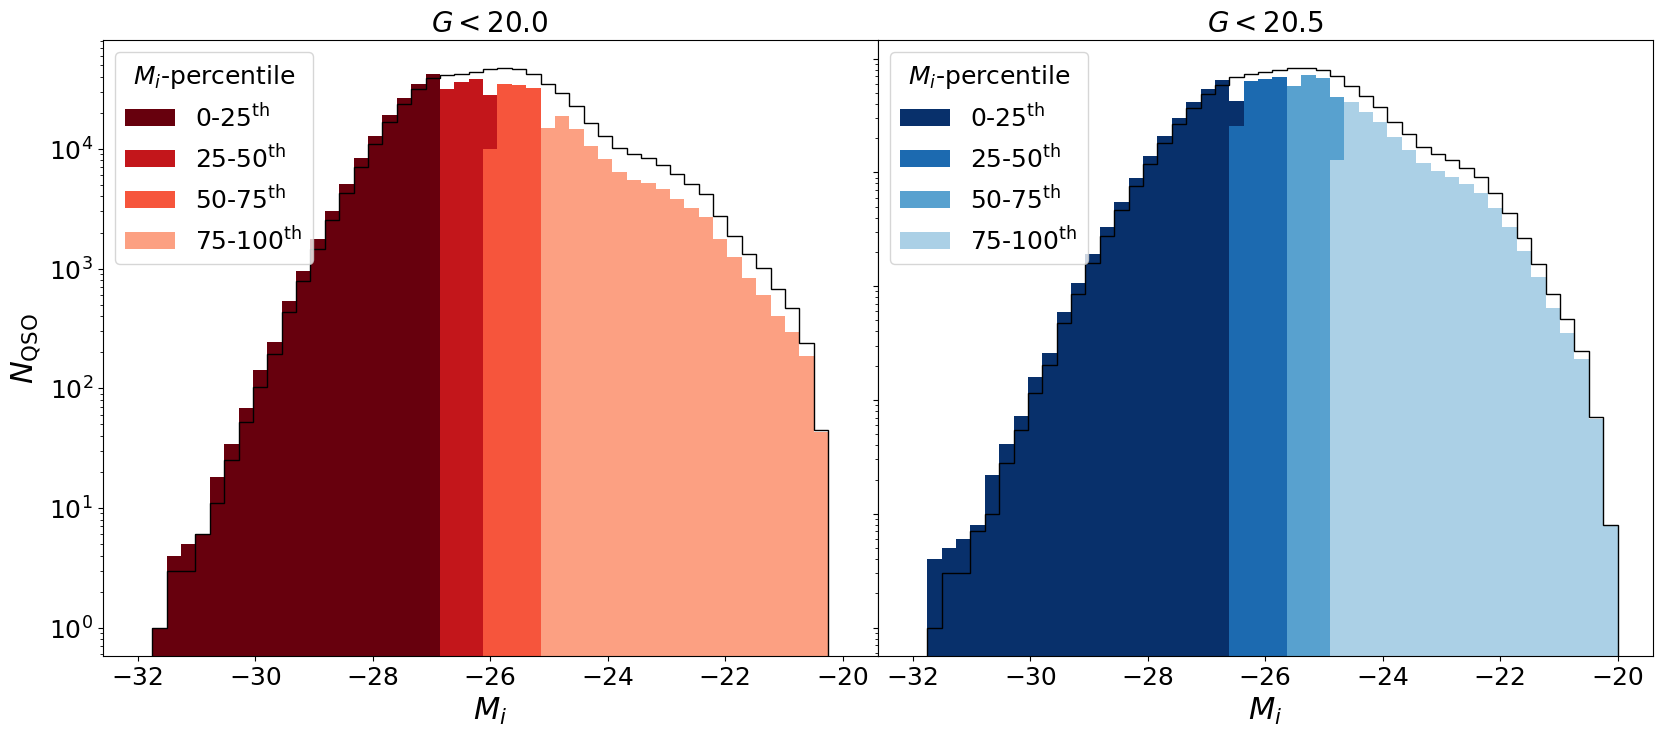

In [20]:
# plot data
bins = np.linspace(-32,-20)
cf = {20.0: [], 20.5: []}

# plot!
fig = plt.figure(figsize = (20, 8))

gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(G_array)):

    fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_array[i])
    selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

    ax1 = fig.add_subplot(gs[i])
    ax1.hist(tabs[i]['M_i'], bins=bins, histtype = 'step', color='black')

    for Lbin, label in zip(L_array, labels):
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _ = quaia.make_bins(G_array[i], Lbin, True, 'L', n_bins = len(L_array),
                                                                                           tab_gcat_type = 'data', method = 'split', fac_rand=25)
        ax1.hist(tab_datahi_mask_zbin0['M_i'], label = label, bins = bins, color = cmaps[i][Lbin])
        
        cf[G_array[i]].append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins))
        print(label, np.min(tab_datahi_mask_zbin0['M_i']), np.max(tab_datahi_mask_zbin0['M_i']), '\n')

    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel('$M_i$')
    ax1.set_yscale('log')
    ax1.legend(title='$M_i$-percentile', title_fontsize = 18)
    if i>0:
        ax1.set_yticklabels([])
    else:
        ax1.set_ylabel('$N_\mathrm{QSO}$')

plt.show()

In [21]:
for Lbin in L_array:
    test = Table.read('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/data/quaia_G20.5_Lsplit3bin{}.fits'.format(i))
    print(len(test))
    print(len(tab_datahi_mask_zbin0)/len(test))

431834
0.48592514716303026
431834
0.48592514716303026
431834
0.48592514716303026
431834
0.48592514716303026


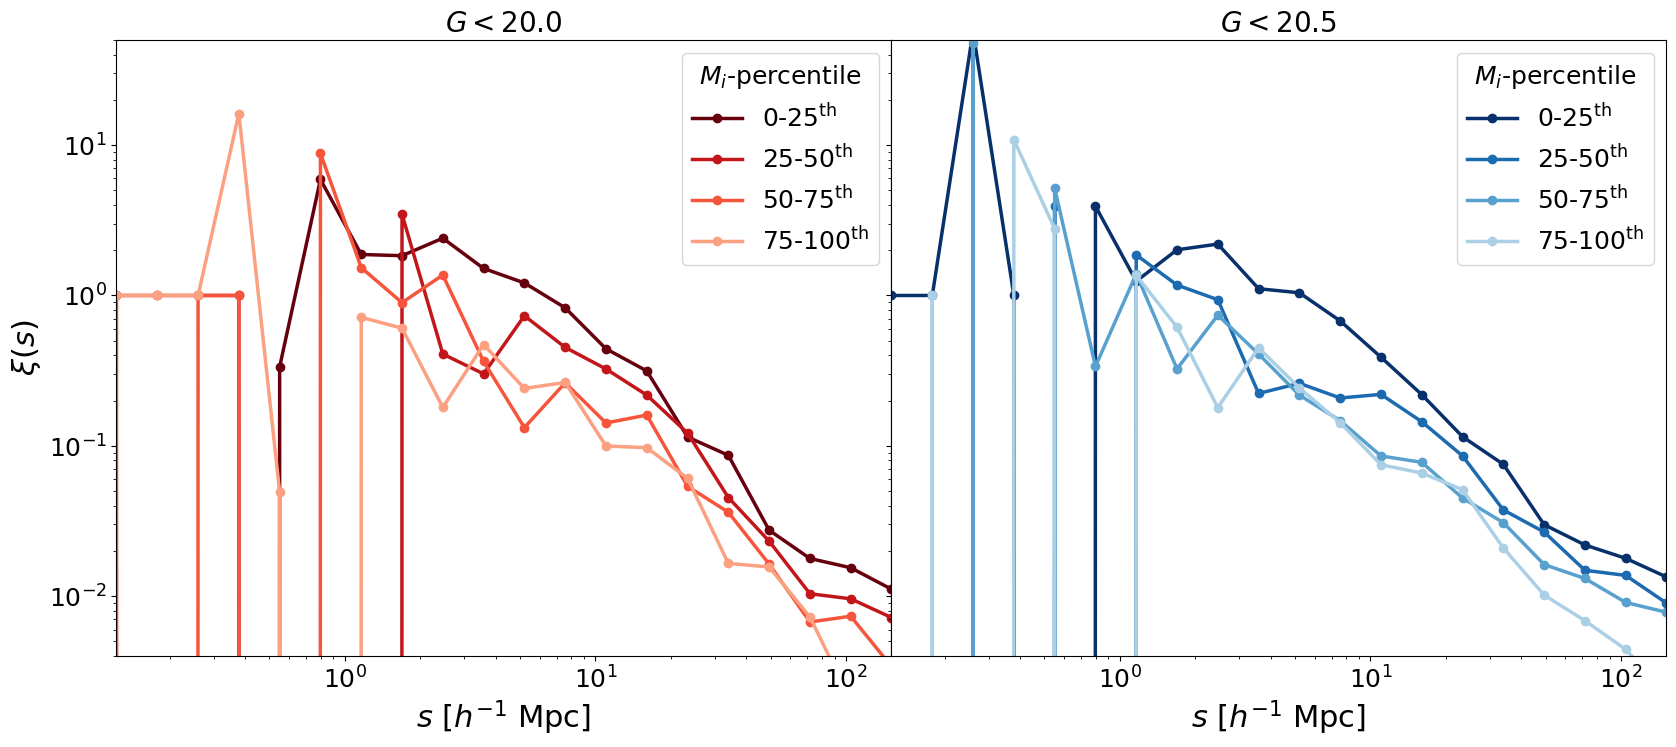

In [22]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', color = cmaps[i][Lbin])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(4e-3, 5e1)
    ax1.legend(title='$M_i$-percentile', title_fontsize = 18)
    if i==0:
        ax1.set_ylabel(r"$\xi(s)$")
    else:
        ax1.set_yticklabels([])

plt.show()

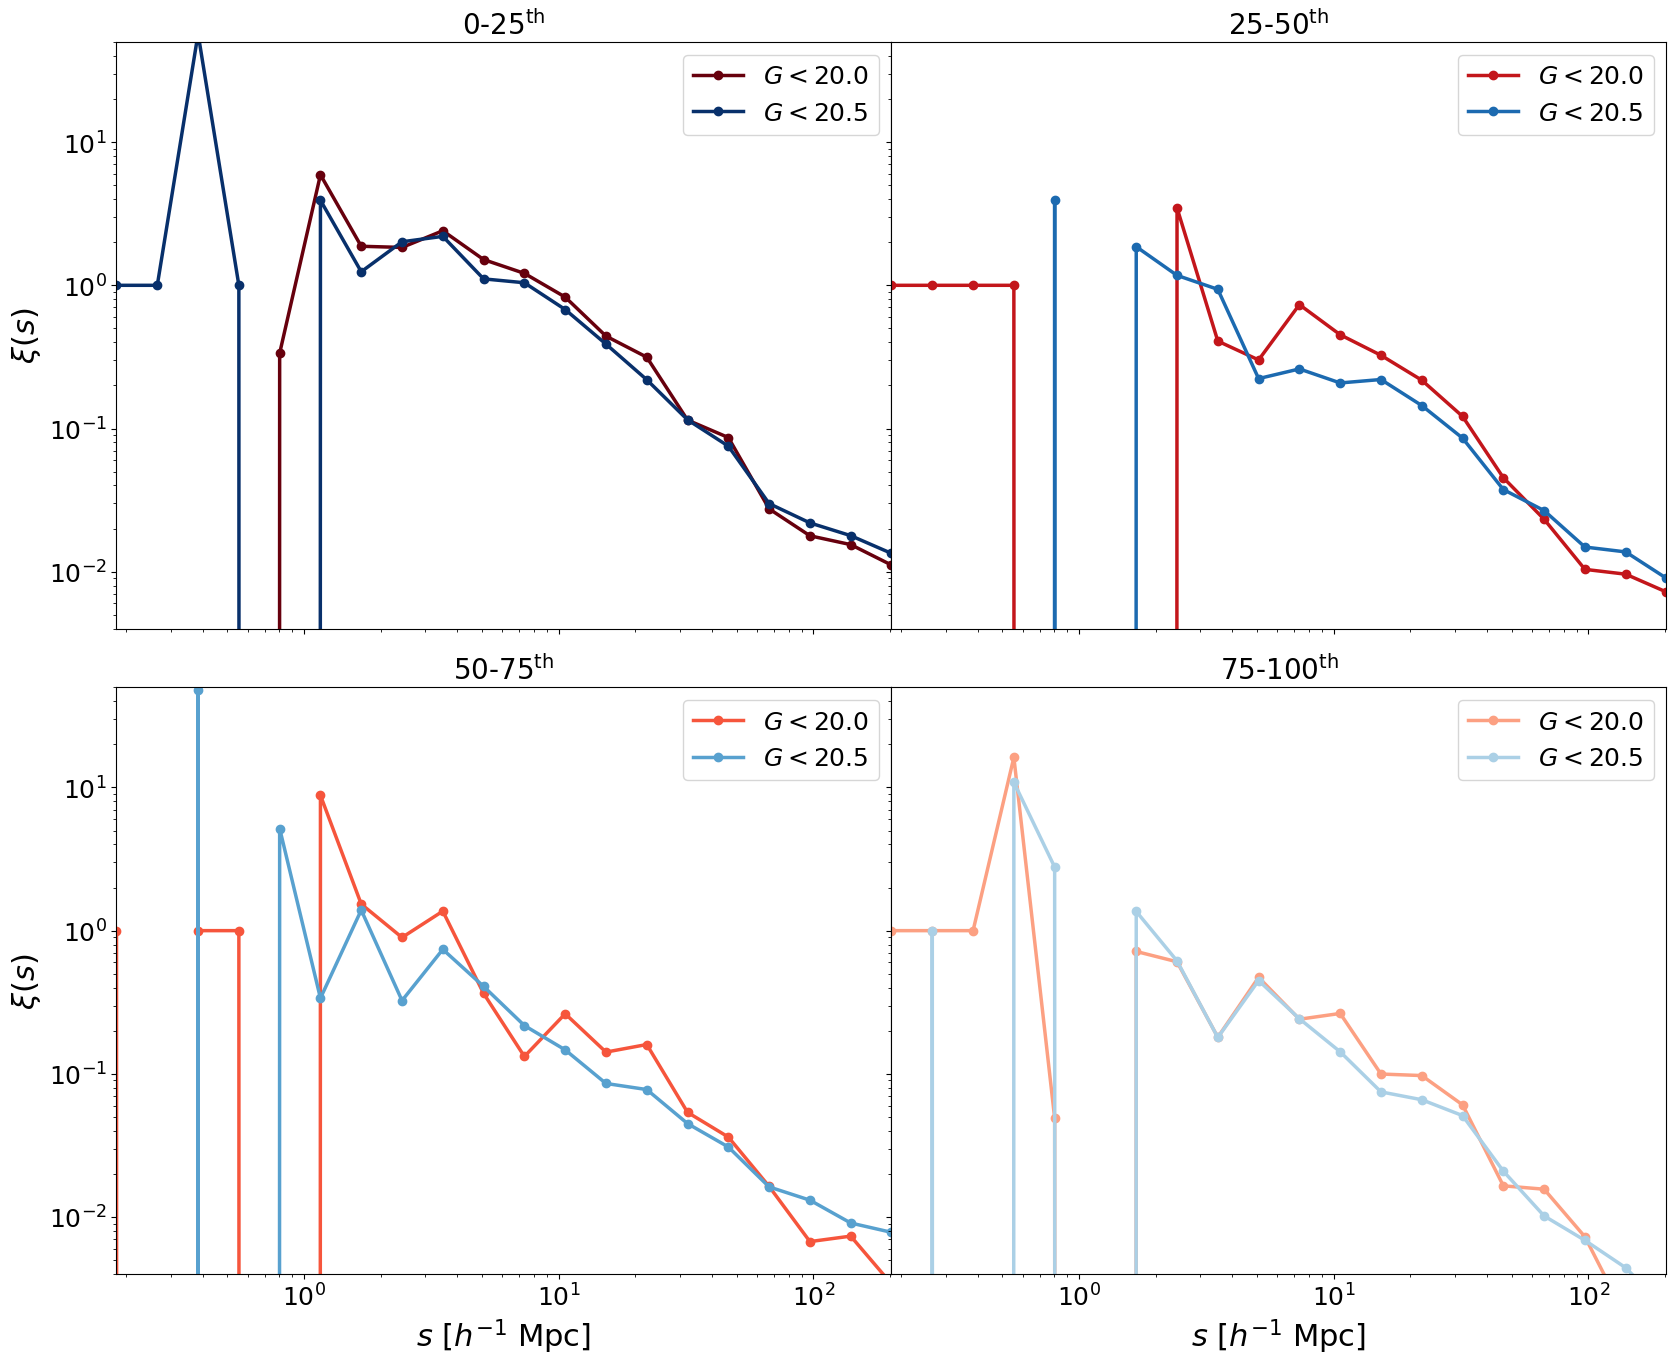

In [35]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])

    for G, cmap in zip(G_array, cmaps):
        
        ax1.plot(quaia.recenter(rbins), cf[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(4e-3, 5e1)
    ax1.legend()
    if Lbin%2==0:
        ax1.set_ylabel(r"$\xi(s)$")
    else:
        ax1.set_yticklabels([])
    if Lbin > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    else: 
        ax1.set_xticklabels([])

plt.show()

## $w_p(r_p)$

In [24]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [25]:
pimax = 80 # 40 # 5000.0 # 40.0

In [45]:
# plot data
# bins = np.linspace(0.08, 4.6)
wp, rpavg = {20.0: [], 20.5: []}, {20.0: [], 20.5: []}
for G in G_array:

    for Lbin in L_array:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _= quaia.make_bins(G, Lbin, True, 'L', n_bins = len(L_array),
                                                                                       tab_gcat_type = 'data', method = 'split', fac_rand = 25)

        wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins,
                                                           nbins = nbins, pimax = pimax)
        wp[G].append(wp_datahi_zbin0)
        rpavg[G].append(rpavg_datahi_zbin0)

_G20.0_Lsplit4bin0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_Lsplit4bin1


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_Lsplit4bin2


...

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_Lsplit4bin2


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_Lsplit4bin3


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


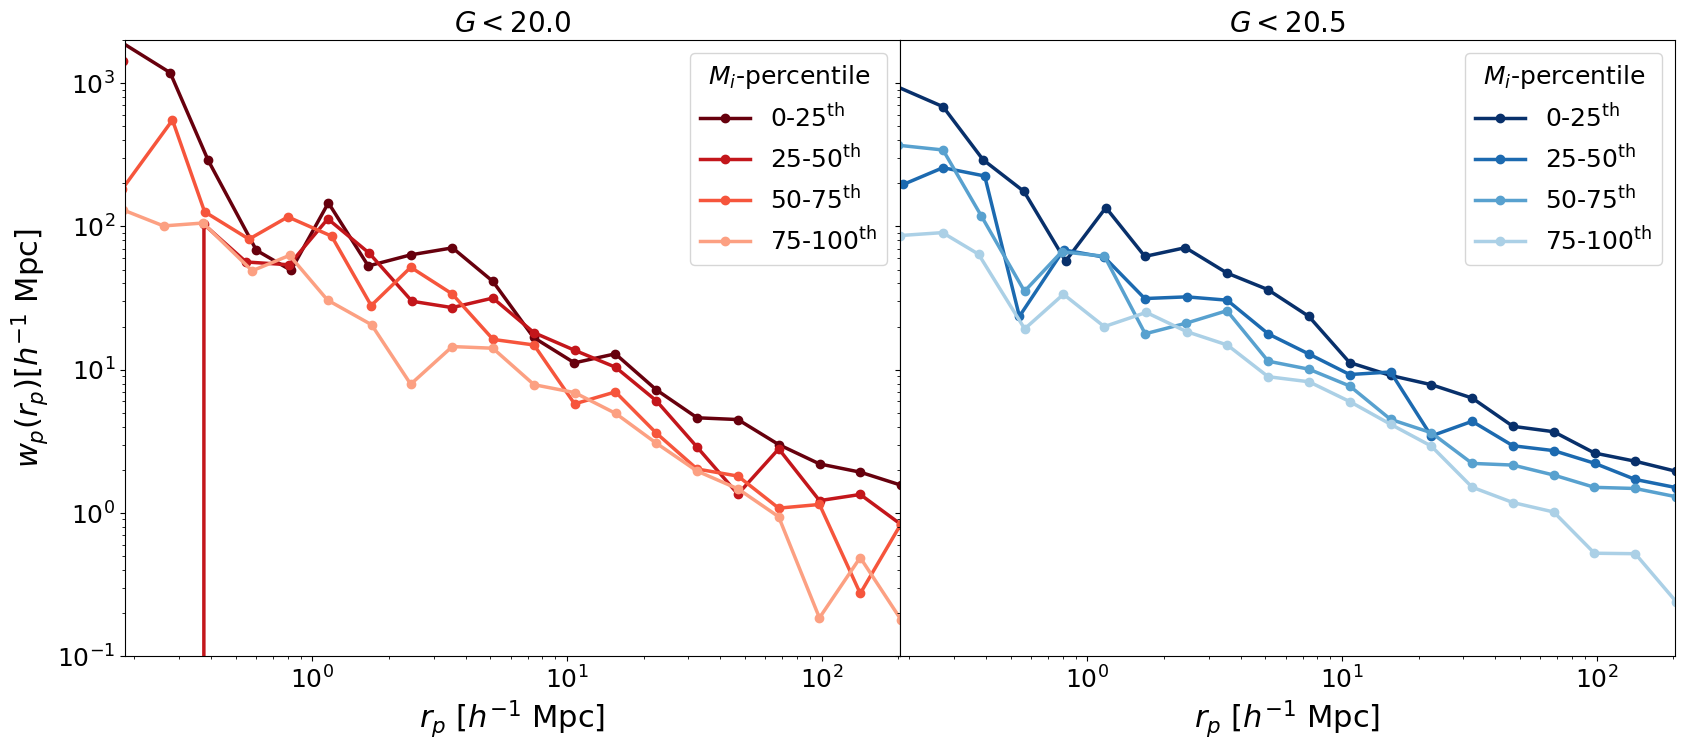

In [61]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(rpavg[G_array[i]][Lbin], wp[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', color = cmaps[i][Lbin])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-1, 2e3)
    ax1.legend(title='$M_i$-percentile', title_fontsize = 18)
    if i==0:
        ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])

plt.show()

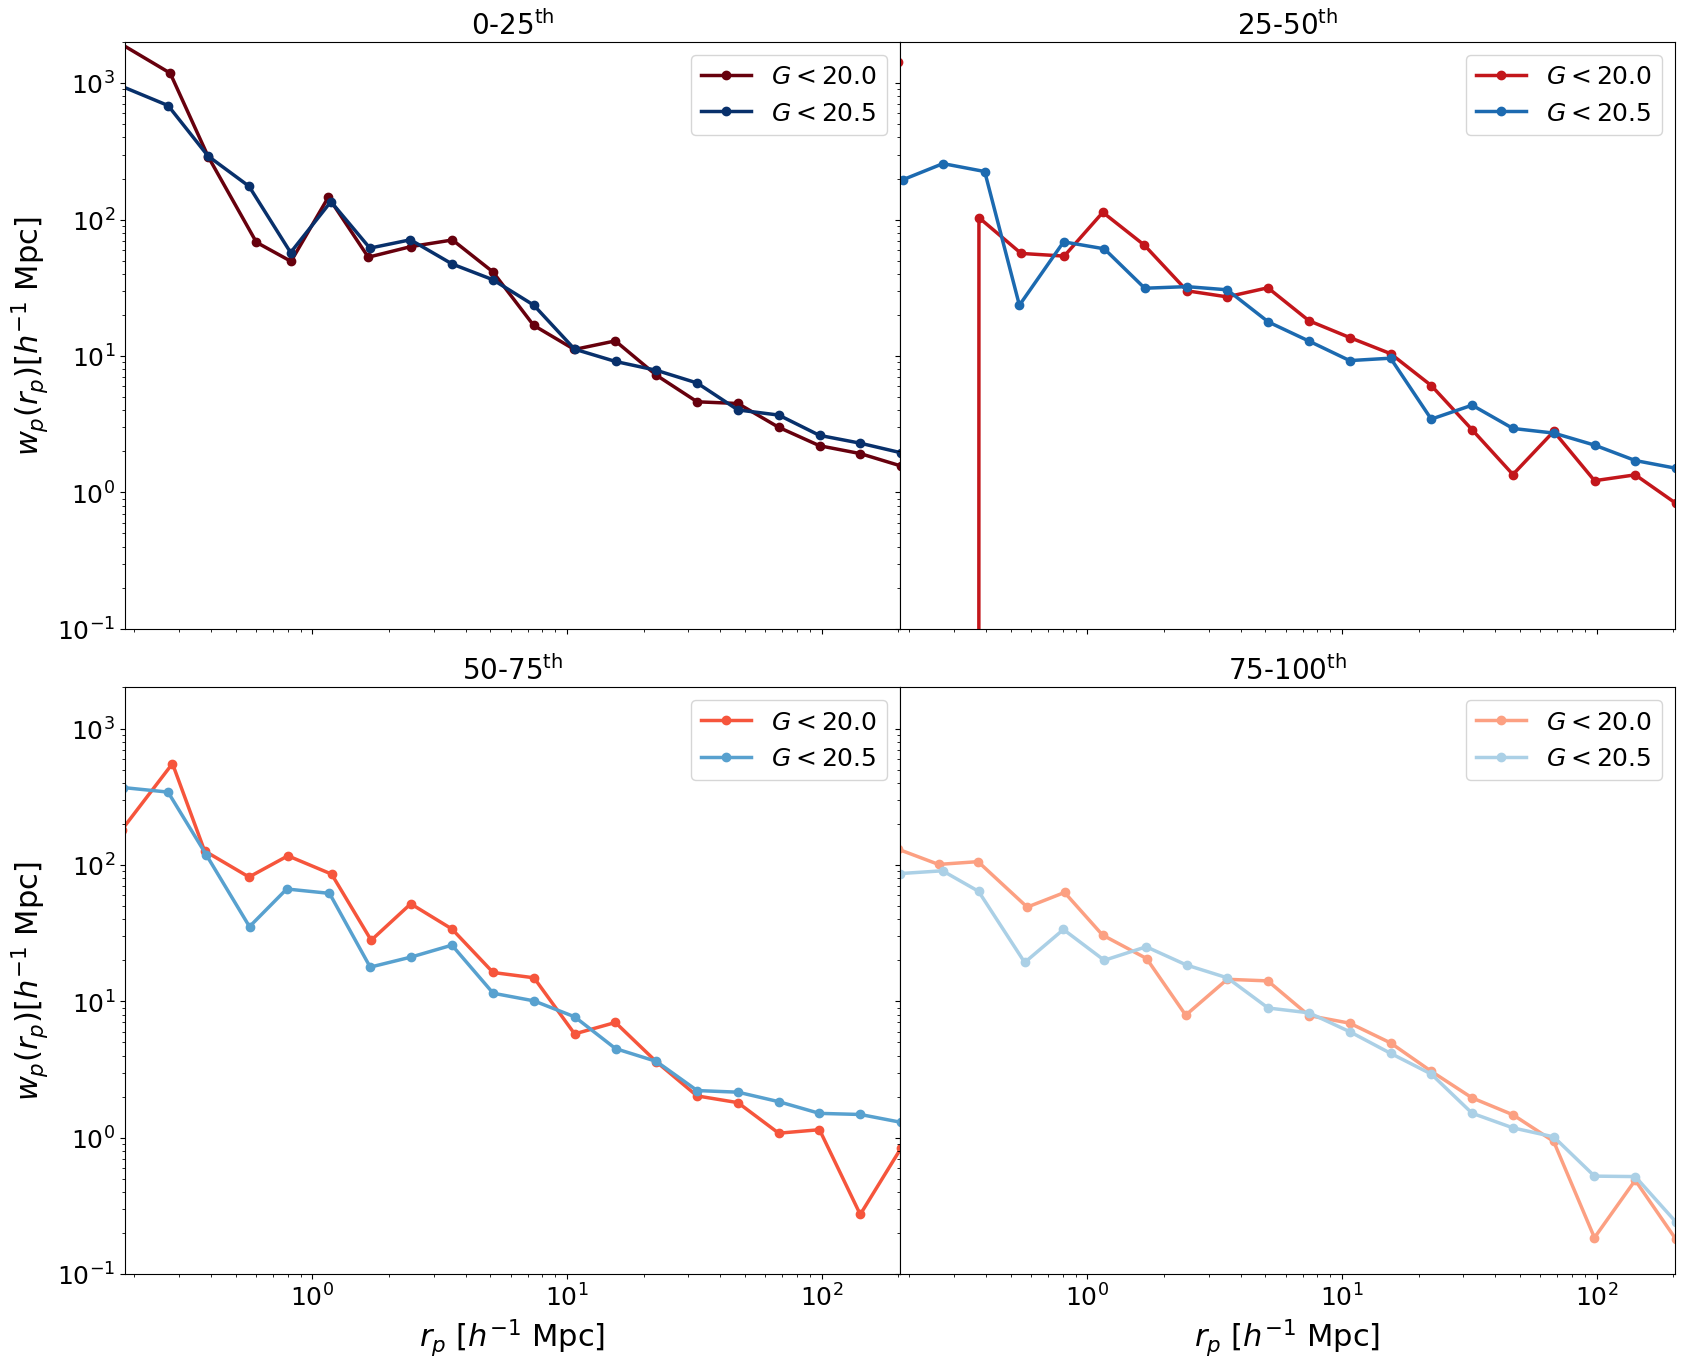

In [62]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(rpavg[G][Lbin], wp[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', color = cmap[Lbin])
    
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-1, 2e3)
    ax1.legend()
    if Lbin%2==0:
        ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])
    if Lbin > 1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else: 
        ax1.set_xticklabels([])

plt.show()

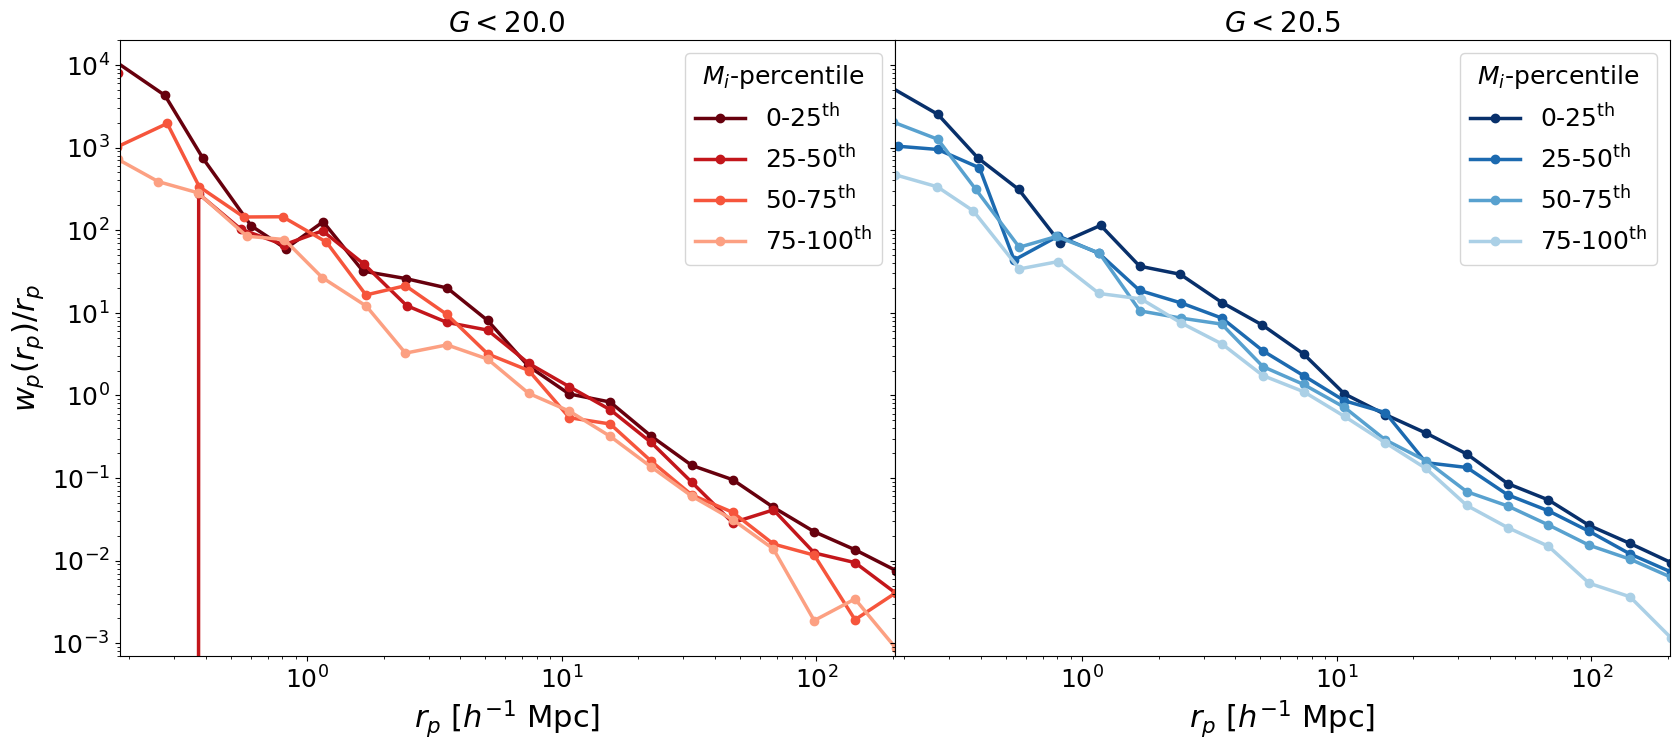

In [75]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(rpavg[G_array[i]][Lbin], wp[G_array[i]][Lbin]/rpavg[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][Lbin])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(7e-4, 2e4)
    ax1.legend(title='$M_i$-percentile', title_fontsize = 18)
    if i==0:
        ax1.set_ylabel(r"$w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])

plt.show()

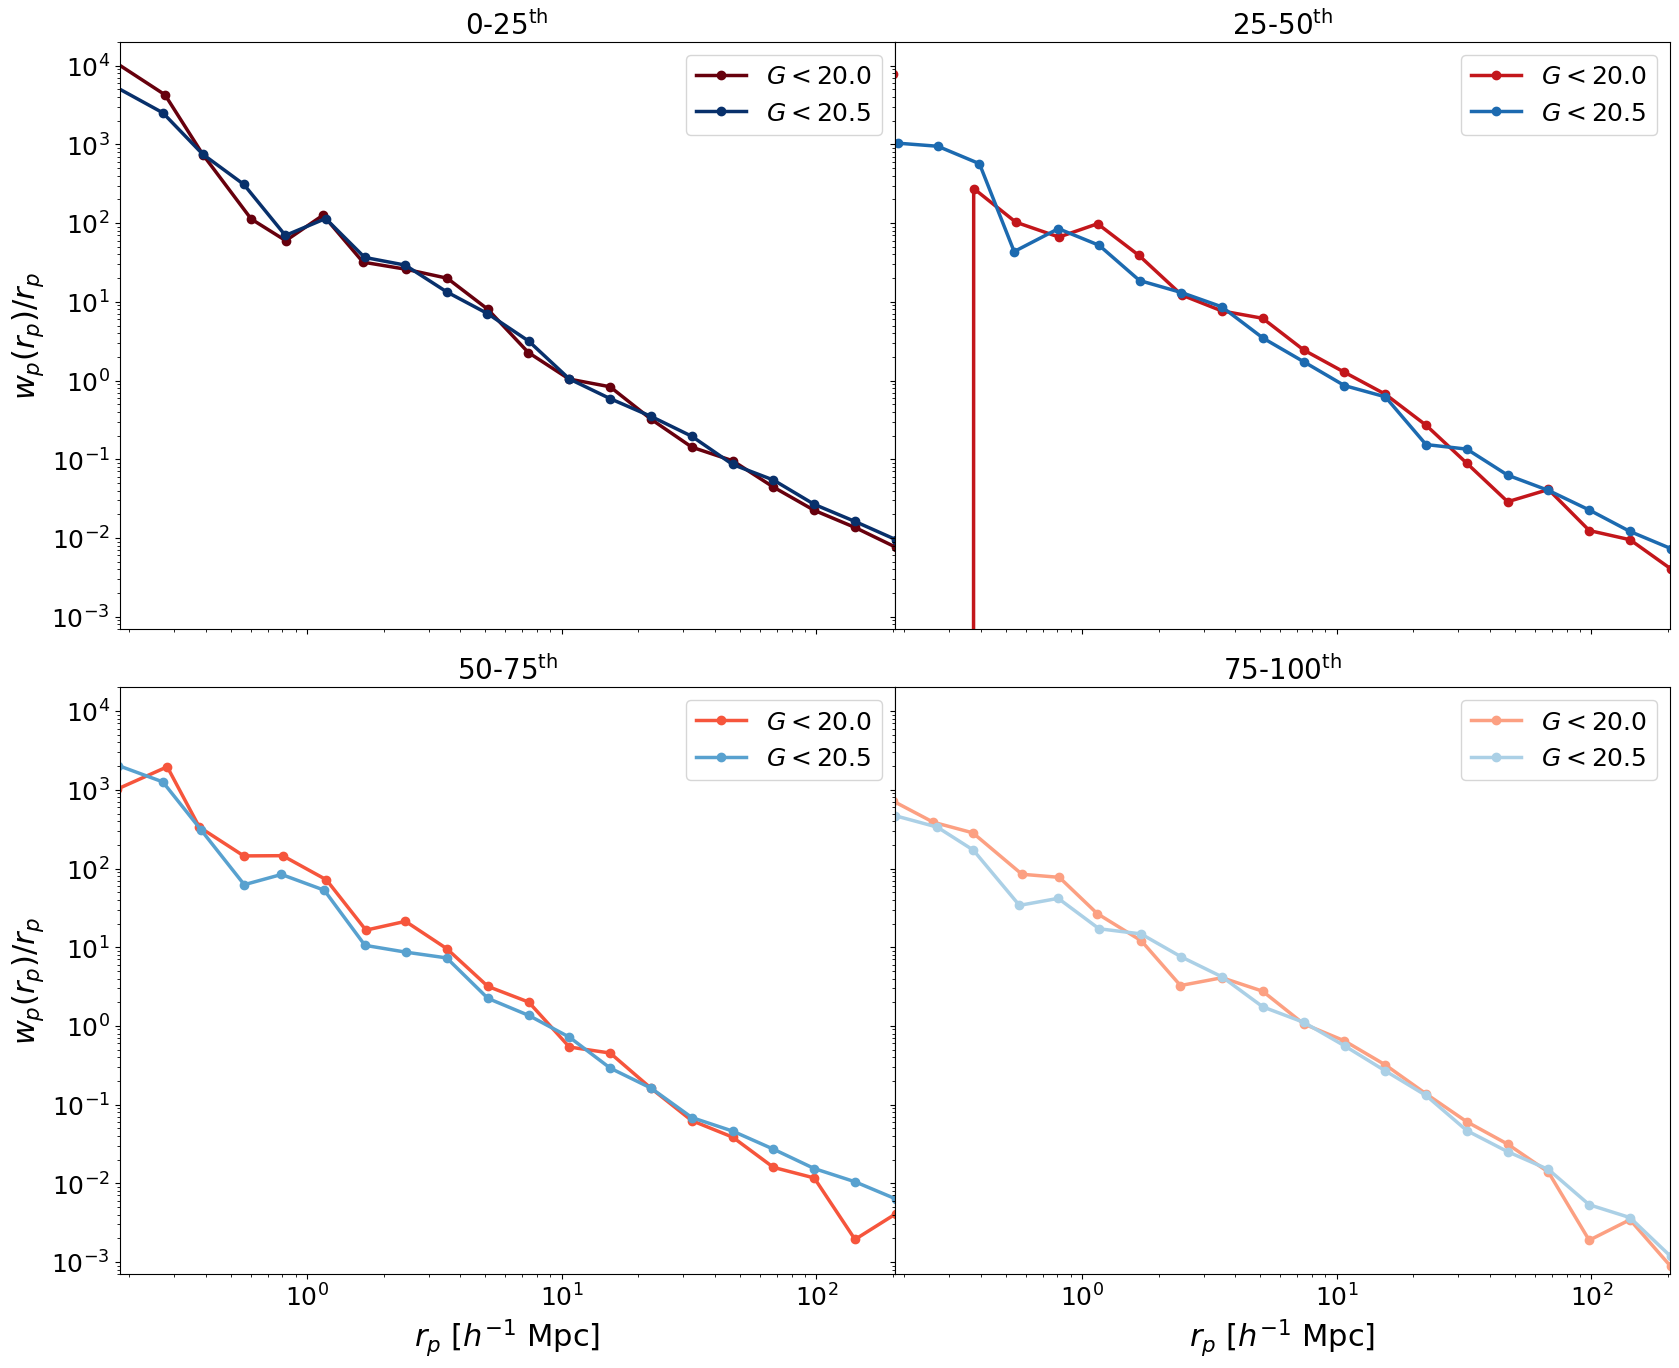

In [76]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(rpavg[G][Lbin], wp[G][Lbin]/rpavg[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(7e-4, 2e4)
    ax1.legend()
    if Lbin%2==0:
        ax1.set_ylabel(r"$w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])
    if Lbin>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])

plt.show()

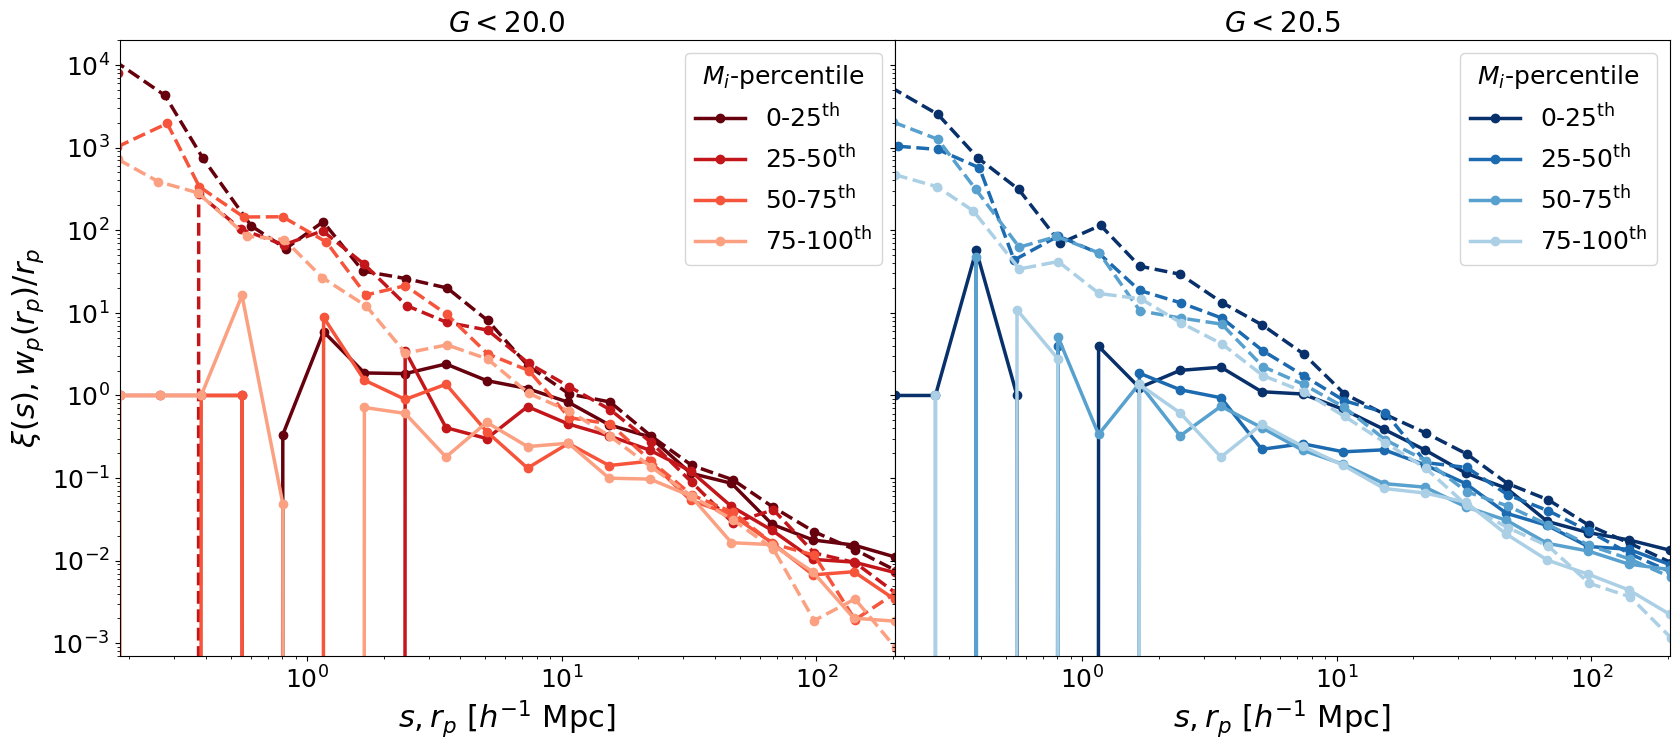

In [77]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', color = cmaps[i][Lbin])
        ax1.plot(rpavg[G_array[i]][Lbin], wp[G_array[i]][Lbin]/rpavg[G_array[i]][Lbin], linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][Lbin], linestyle = '--')
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(7e-4, 2e4)
    ax1.legend(title='$M_i$-percentile', title_fontsize = 18)
    if i==0:
        ax1.set_ylabel(r"$\xi(s), w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])

plt.show()

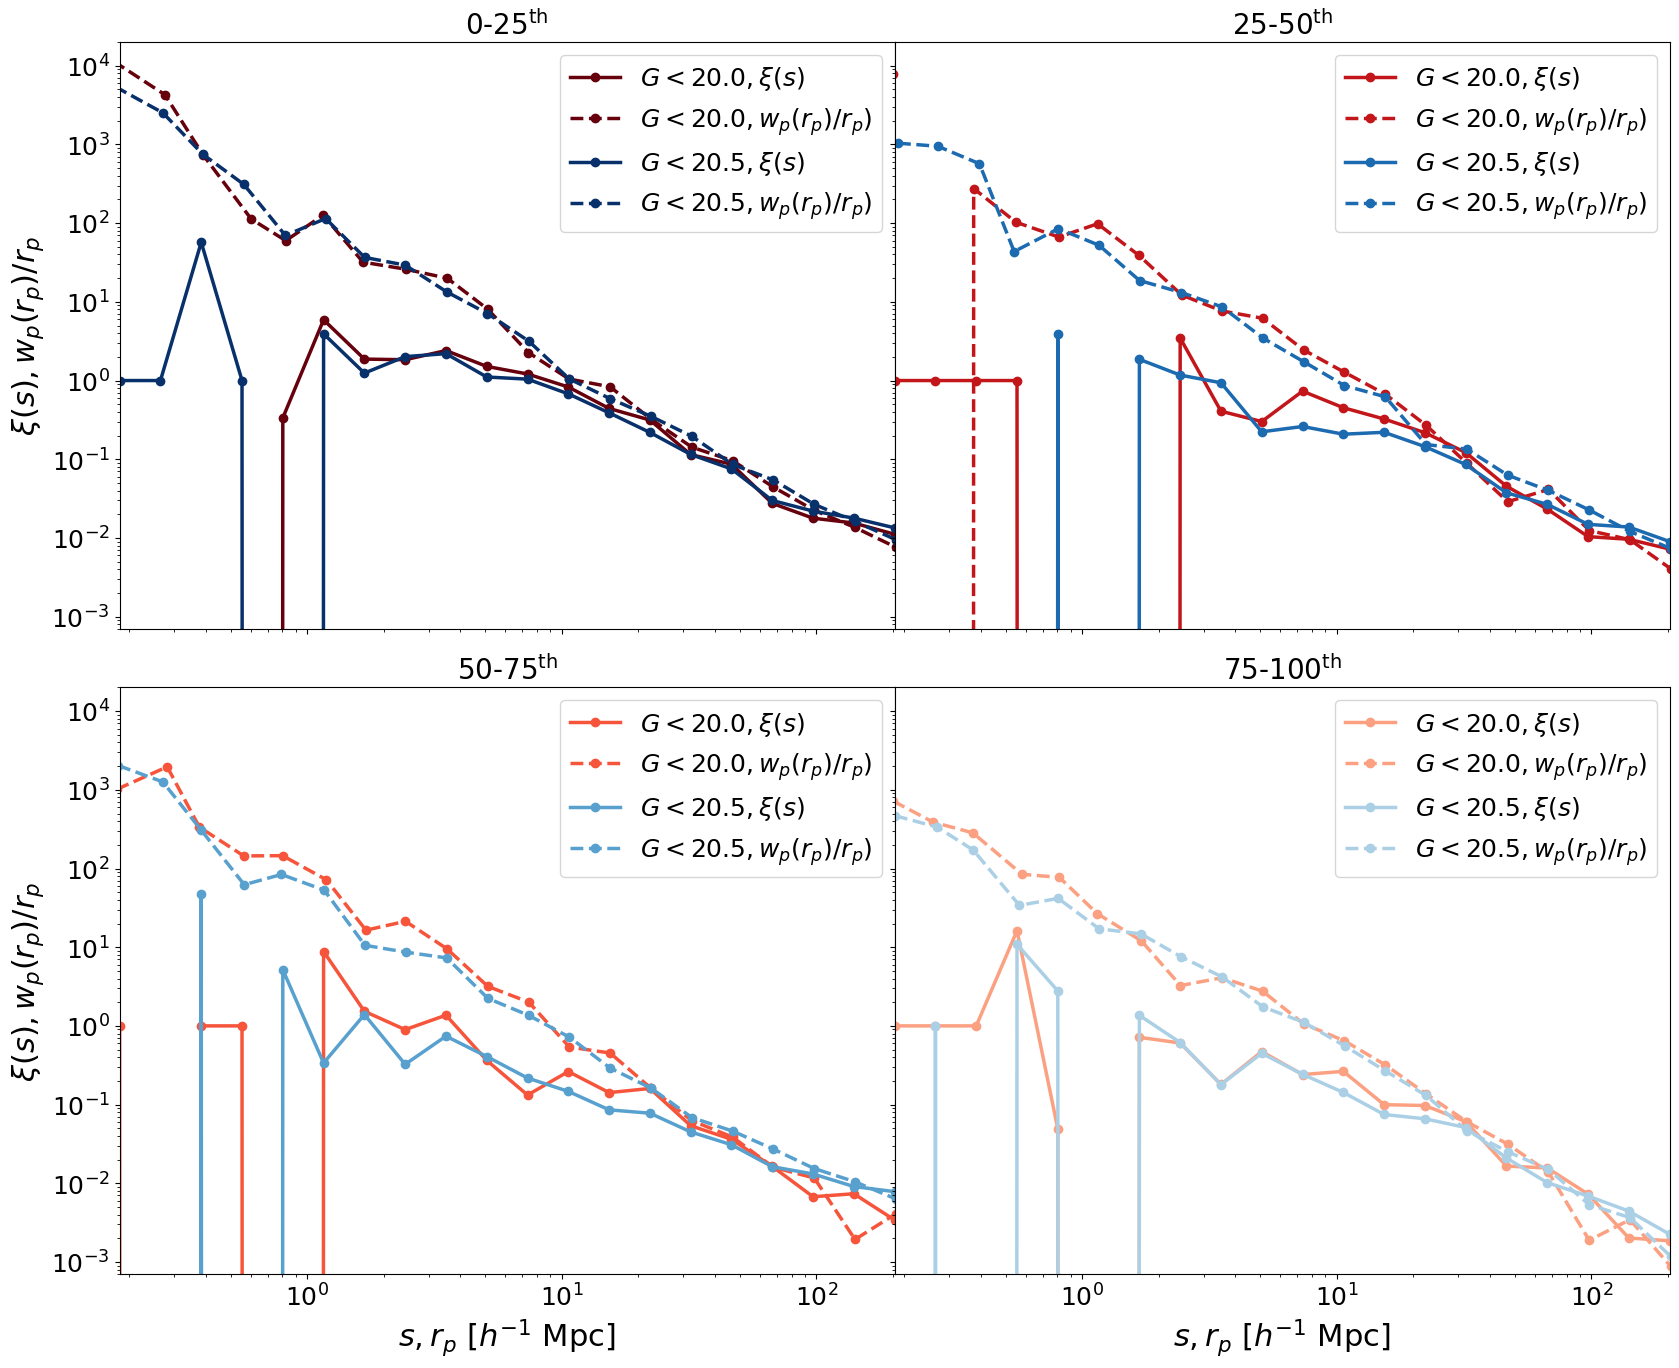

In [78]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(quaia.recenter(rbins), cf[G][Lbin], label = '$G<{}, \\xi(s)$'.format(G), linewidth = 2.5, marker = 'o', color = cmap[Lbin])
        ax1.plot(rpavg[G][Lbin], wp[G][Lbin]/rpavg[G][Lbin], label = '$G<{}, w_p(r_p)/r_p)$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin], linestyle = '--')
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(7e-4, 2e4)
    ax1.legend()
    if Lbin%2==0:
        ax1.set_ylabel(r"$\xi(s), w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])
    if Lbin>1:
        ax1.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])

plt.show()

## $w(\theta)$

In [52]:
# Create the bins array
# thetabins = np.logspace(np.log10(0.1), np.log10(10), 15) 
thetabins = np.logspace(np.log10(0.1), np.log10(35), 15) #(np.log10(0.15), np.log10(35), 15)

In [53]:
# plot data
wtheta = {20.0: [], 20.5: []}
for G in G_array:

    for Lbin in L_array:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, _, _, _ = quaia.make_bins(G, Lbin, True, 'L',n_bins = len(L_array), tab_gcat_type = 'data',
                                                                                method = 'split', z = False, fac_rand = 25)

        wtheta_datahi_zbin0 = quaia.w_theta(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, nthreads = nthreads, thetabins = thetabins)
        wtheta[G].append(wtheta_datahi_zbin0)

_G20.0_Lsplit4bin0
DD: 0.366983
DR: 18.704168
RR: 216.425356
_G20.0_Lsplit4bin1
DD: 0.273575
DR: 15.167072
RR: 175.782224
_G20.0_Lsplit4bin2
DD: 0.276937
DR: 13.766013
RR: 146.551941
_G20.0_Lsplit4bin3
DD: 0.275134
DR: 11.917154
RR: 149.717479
_G20.5_Lsplit4bin0
DD: 1.35637
DR: 74.336711
RR: 1170.822066
_G20.5_Lsplit4bin1
DD: 1.911093
DR: 99.132
RR: 1382.675285
_G20.5_Lsplit4bin2
DD: 3.438101
DR: 137.975541
RR: 1136.960784
_G20.5_Lsplit4bin3
DD: 2.362365
DR: 99.892103
RR: 952.767671


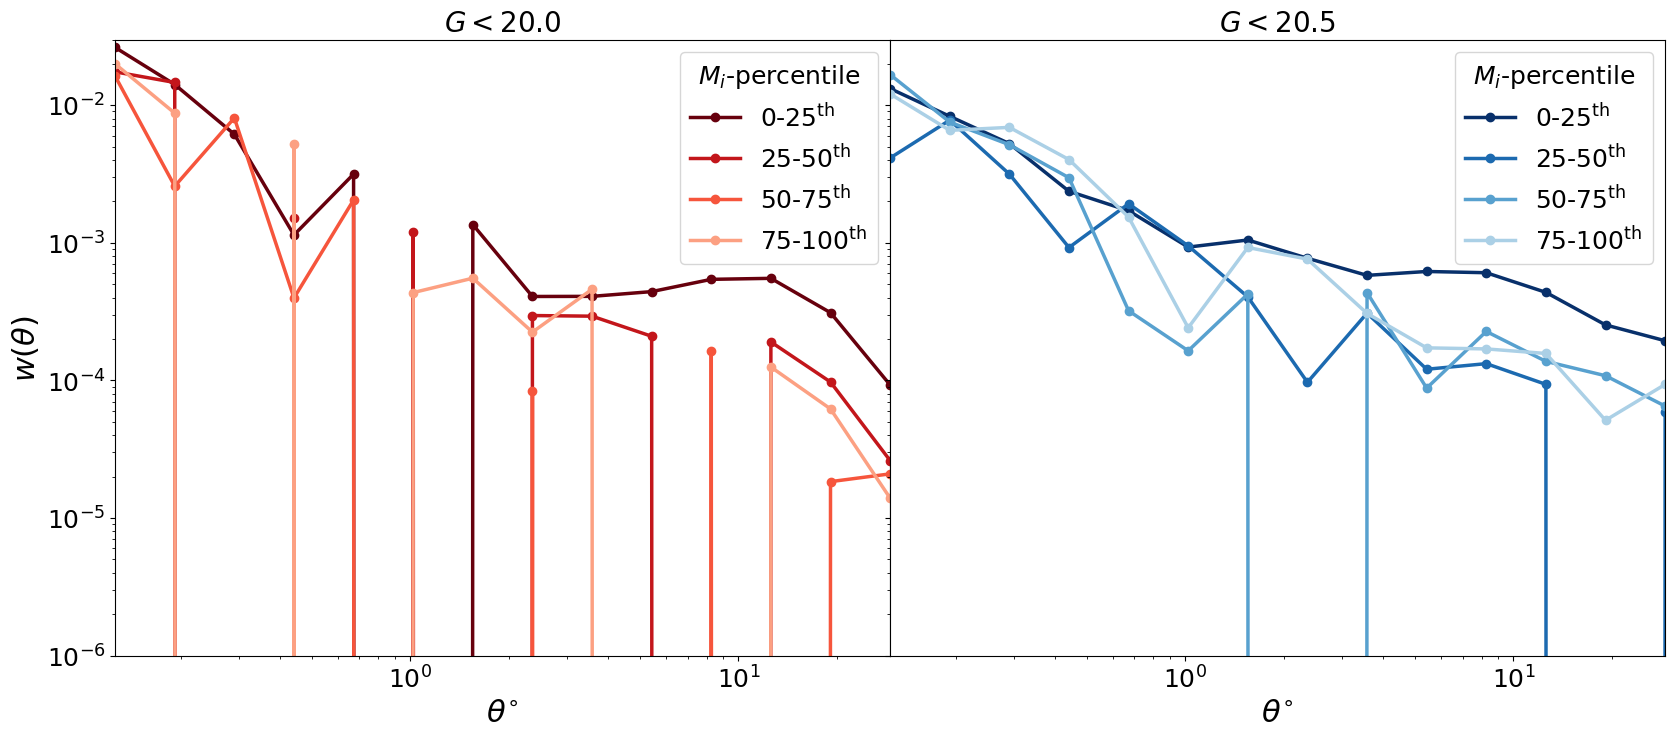

In [54]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][Lbin])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$\theta^{\circ}$')
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
    ax1.set_ylim(1e-6, 3e-2)
    ax1.legend(title='$M_i$-percentile', title_fontsize = 18)
    if i==0:
        ax1.set_ylabel(r"$w(\theta)$")
    else:
        ax1.set_yticklabels([])

plt.show()

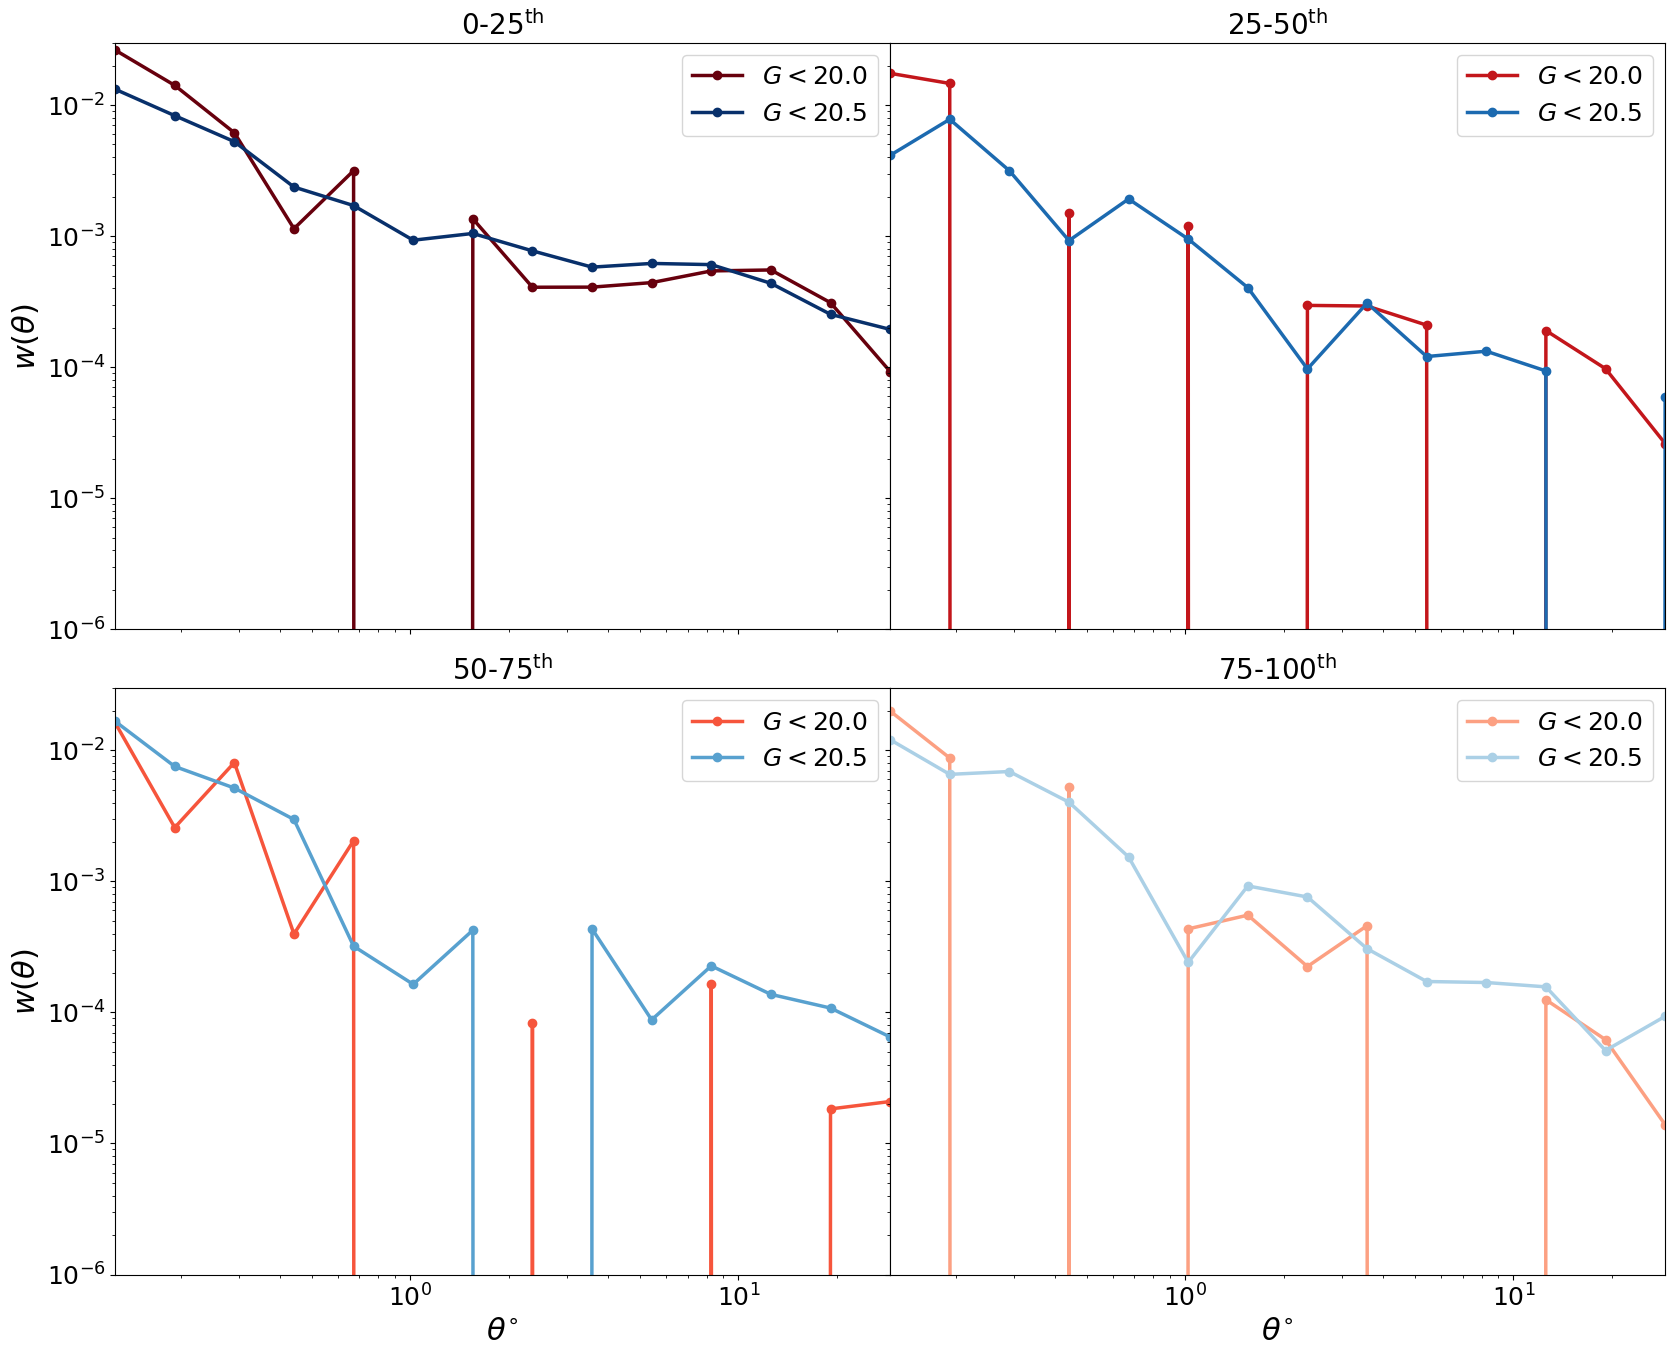

In [55]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):

    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(quaia.recenter(thetabins), wtheta[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
    ax1.set_ylim(1e-6, 3e-2)
    ax1.legend()
    if Lbin%2==0:
        ax1.set_ylabel(r"$w(\theta)$")
    else:
        ax1.set_yticklabels([])
    if Lbin>1:
        ax1.set_xlabel(r'$\theta^{\circ}$')
    else:
        ax1.set_xticklabels([])

plt.show()